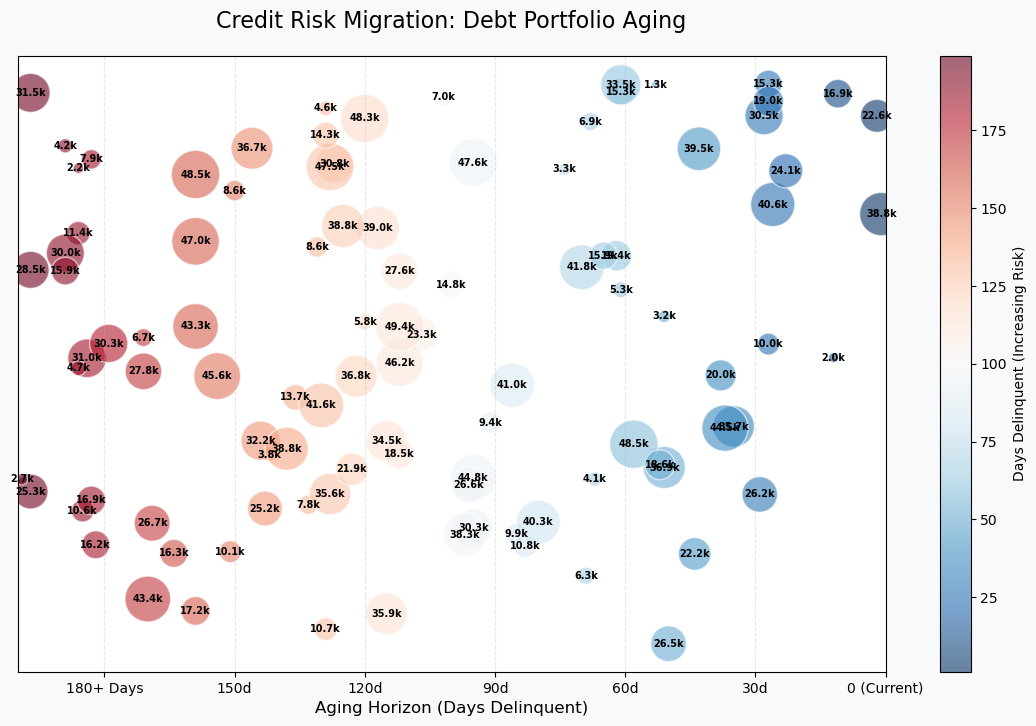

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate Synthetic Portfolio Data
np.random.seed(42)
n_accounts = 100
debt_owed = np.random.uniform(1000, 50000, n_accounts) # $1k to $50k
days_delinquent = np.random.randint(0, 200, n_accounts)

# 2. Probability of Collection Logic
# Decay function: Probability hits 0% at 180 days
prob_collection = np.clip(1 - (days_delinquent / 180), 0, 1)

# 3. Create Migration Visualization
plt.figure(figsize=(14, 8), facecolor='#f8f9fa')

# Scatter Plot:
# X: Days Delinquent (Flipped in axis formatting)
# s: Circle size based on debt amount
# c: Color based on age (Blue to Red)
scatter = plt.scatter(
    days_delinquent, 
    np.random.uniform(10, 90, n_accounts), # Random vertical jitter
    s=debt_owed/40, 
    c=days_delinquent, 
    cmap='RdBu_r', 
    alpha=0.6, 
    edgecolors='white'
)

# Overlay "amount k" labels on each circle
for i in range(n_accounts):
    plt.text(
        days_delinquent[i], 
        plt.gca().collections[0].get_offsets()[i][1], 
        f"{debt_owed[i]/1000:.1f}k", 
        fontsize=7, ha='center', va='center', fontweight='bold'
    )

# 4. Axis Formatting for Right-to-Left Aging
plt.xlim(200, 0) # Flip: 0 on right, 180+ on left
plt.xticks([180, 150, 120, 90, 60, 30, 0], 
           ['180+ Days', '150d', '120d', '90d', '60d', '30d', '0 (Current)'])

plt.title('Credit Risk Migration: Debt Portfolio Aging', fontsize=16, pad=20)
plt.xlabel('Aging Horizon (Days Delinquent)', fontsize=12)
plt.yticks([]) # Hide Y-axis as it represents random jitter
plt.grid(axis='x', linestyle='--', alpha=0.3)

# Add Colorbar for Risk Context
cbar = plt.colorbar(scatter)
cbar.set_label('Days Delinquent (Increasing Risk)')

plt.show()